# Modelagem
Esta seção corresponde a modelagem do estado para a resolução do problema.

In [ ]:
%%writefile estado.py
class Estado:
    """
        cidade_atual: índice da cidade atual
        visitadas: bitmask indicando cidades visitadas
        pai: referência ao estado anterior
        custo: custo acumulado
    """

    __slots__ = ('cidade_atual', 'visitadas', 'pai', 'custo')

    def __init__(self, cidade_atual, visitadas, pai, custo):
        """
        Cria um novo estado.
        """
        self.cidade_atual = cidade_atual

        # Converte para bitmask se necessário
        if isinstance(visitadas, (set, frozenset)):
            self.visitadas = self._set_to_bitmask(visitadas)
        else:
            self.visitadas = visitadas  # já é bitmask

        self.pai = pai
        self.custo = custo

    @staticmethod
    def _set_to_bitmask(cidades):
        """
        Converte um conjunto de cidades para bitmask.

        Exemplo: {0, 2, 3} -> 0b1101 = 13
        """
        bitmask = 0
        for cidade in cidades:
            bitmask |= (1 << cidade)  # liga o bit da cidade
        return bitmask

    @staticmethod
    def _bitmask_to_set(bitmask):
        """
        Converte bitmask para conjunto de cidades.

        Exemplo: 0b1101 (13) -> {0, 2, 3}
        """
        cidades = set()
        cidade = 0
        while bitmask:
            if bitmask & 1:  # bit mais à direita está ligado?
                cidades.add(cidade)
            bitmask >>= 1  # shift right
            cidade += 1
        return cidades

    def cidade_foi_visitada(self, cidade):
        """
        Verifica se uma cidade foi visitada.

        Exemplo: visitadas = 0b1101, cidade = 2
                 0b1101 & 0b0100 = 0b0100 (True)
        """
        return (self.visitadas & (1 << cidade)) != 0

    def ja_visitei_todas(self, total_cidades):
        """
        Verifica se todas as cidades foram visitadas.

        Conta quantos bits estão ligados e compara com total.
        """
        # Conta bits ligados (população de bits)
        contador = 0
        bitmask = self.visitadas
        while bitmask:
            contador += bitmask & 1
            bitmask >>= 1
        return contador == total_cidades

    def obter_visitadas_como_set(self):
        """
        Retorna as cidades visitadas como conjunto (para debug/compatibilidade).
        """
        return self._bitmask_to_set(self.visitadas)

    def adicionar_cidade(self, cidade):
        """
        Retorna novo bitmask com a cidade adicionada.

        Exemplo: visitadas = 0b1101, cidade = 1
                 novo = 0b1101 | 0b0010 = 0b1111
        """
        return self.visitadas | (1 << cidade)

    def reconstruir_caminho(self):
        """
        Reconstrói o caminho completo seguindo os pais.

        Retorna:
            lista com a sequência de cidades percorridas
        """
        caminho = []
        estado_atual = self

        # Segue a cadeia de pais até o início
        while estado_atual is not None:
            caminho.append(estado_atual.cidade_atual)
            estado_atual = estado_atual.pai

        # Inverte porque construímos de trás pra frente
        caminho.reverse()

        return caminho

    def __eq__(self, outro):
        """
        Compara se dois estados são iguais.
        """
        return (self.cidade_atual == outro.cidade_atual and
                self.visitadas == outro.visitadas)

    def __hash__(self):
        """
        Hash para colocar estados em conjuntos/dicionários.
        """
        return hash((self.cidade_atual, self.visitadas))

    def __repr__(self):
        """Representação textual para debug"""
        # Mostra bitmask em binário
        num_visitadas = bin(self.visitadas).count('1')
        return f"Estado(cidade={self.cidade_atual}, visitadas={num_visitadas}/{bin(self.visitadas)}, custo={self.custo:.0f})"


def bitmask_vazio():
    """Retorna bitmask vazio (nenhuma cidade visitada)"""
    return 0


def criar_bitmask_completo(n):
    """
    Cria bitmask com todas as n primeiras cidades marcadas.

    Exemplo: n=4 -> 0b1111 = 15
    """
    return (1 << n) - 1


def obter_cidades_nao_visitadas(visitadas_bitmask, total_cidades):
    """
    Retorna conjunto de cidades NÃO visitadas.

    Parâmetros:
        visitadas_bitmask: bitmask com cidades visitadas
        total_cidades: número total de cidades

    Retorna:
        índices das cidades não visitadas
    """
    nao_visitadas = set()
    for cidade in range(total_cidades):
        if (visitadas_bitmask & (1 << cidade)) == 0:  # bit está desligado?
            nao_visitadas.add(cidade)
    return nao_visitadas


Overwriting estado.py


# Algoritmos implementados.
Esta seção corresponde aos algoritmos solicitados na descrição do trabalho.
- [x] Busca em Largura (BFS)
- [x] Busca em Profundidade (DFS)
- [x] Busca de Custo Uniforme (UCS)
- [x] Busca Gulosa (Greedy Search)
- [x] Algoritmo A* (A-Star)

In [ ]:
%%writefile bfs.py
import time
import sys
import os
from collections import deque

from estado import Estado, obter_cidades_nao_visitadas


class BuscaLargura:
    def __init__(self, grafo, cidade_inicial=0):
        """
        Parâmetros:
            grafo: matriz de distâncias entre cidades
            cidade_inicial: cidade de partida (padrão: 0)
        """
        self.grafo = grafo
        self.num_cidades = len(grafo)
        self.cidade_inicial = cidade_inicial

        # Métricas
        self.nos_gerados = 0
        self.nos_expandidos = 0
        self.tempo_execucao = 0
        self.solucoes_encontradas = 0
        self.tamanho_maximo_fila = 0

        # Solução
        self.melhor_custo = None
        self.melhor_caminho = None

    def expandir(self, estado):
        """
        Expande um estado gerando seus sucessores.
        """
        self.nos_expandidos += 1
        sucessores = []

        # Obtém cidades não visitadas usando bitmask
        nao_visitadas = obter_cidades_nao_visitadas(
            estado.visitadas,
            self.num_cidades
        )

        # Gera um sucessor para cada cidade não visitada
        for proxima in nao_visitadas:
            # Adiciona cidade ao bitmask (operação O(1)!)
            novo_bitmask = estado.visitadas | (1 << proxima)

            custo_aresta = self.grafo[estado.cidade_atual][proxima]
            novo_custo = estado.custo + custo_aresta

            # Cria novo estado com bitmask
            novo_estado = Estado(
                cidade_atual=proxima,
                visitadas=novo_bitmask,  # passa bitmask direto
                pai=estado,
                custo=novo_custo
            )

            sucessores.append(novo_estado)
            self.nos_gerados += 1

        return sucessores

    def buscar(self, verbose=False):
        """
        Parâmetros:
            verbose: Se True, mostra progresso por nível

        Retorna:
            melhor estado encontrado
        """
        inicio = time.time()

        # Estado inicial
        # Bitmask com apenas bit cidade_inicial ligado
        bitmask_inicial = 1 << self.cidade_inicial

        inicial = Estado(
            cidade_atual=self.cidade_inicial,
            visitadas=bitmask_inicial,
            pai=None,
            custo=0
        )

        # Fila FIFO
        fila = deque([inicial])

        # Melhor solução
        melhor = None
        melhor_custo = float('inf')

        # Controle de nível (para verbose)
        nivel_anterior = 1

        # Loop principal
        while fila:
            # Rastreia tamanho máximo da fila
            if len(fila) > self.tamanho_maximo_fila:
                self.tamanho_maximo_fila = len(fila)

            # Remove do INÍCIO da fila (FIFO)
            estado = fila.popleft()

            # Conta bits ligados para saber o nível (número de cidades visitadas)
            nivel_atual = bin(estado.visitadas).count('1')

            # Mostra progresso por nível
            if verbose and nivel_atual > nivel_anterior:
                print(f"  Nível {nivel_atual}: {self.nos_expandidos:,} nós expandidos, "
                      f"fila: {len(fila):,} estados")
                nivel_anterior = nivel_atual

            # Teste de objetivo: visitou todas as cidades?
            if estado.ja_visitei_todas(self.num_cidades):
                # Custo total (inclui volta ao início)
                custo_volta = self.grafo[estado.cidade_atual][self.cidade_inicial]
                custo_total = estado.custo + custo_volta

                self.solucoes_encontradas += 1

                # Atualiza se for melhor
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor = estado

                    if verbose:
                        print(f" Nova melhor solução! Custo: {melhor_custo}")

                continue

            # Expande e adiciona sucessores no FINAL da fila
            for sucessor in self.expandir(estado):
                fila.append(sucessor)

        # Finaliza
        self.tempo_execucao = time.time() - inicio

        if melhor:
            self.melhor_custo = melhor_custo
            # Reconstrói o caminho apenas ao final
            self.melhor_caminho = melhor.reconstruir_caminho() + [self.cidade_inicial]

        return melhor

    def imprimir_resultados(self):
        """Imprime resultados da busca"""
        print("\n" + "="*70)
        print("BUSCA EM LARGURA (BFS) - RESULTADOS")
        print("="*70)

        print(f"\nMÉTRICAS:")
        print(f"  Nós gerados:           {self.nos_gerados:,}")
        print(f"  Nós expandidos:        {self.nos_expandidos:,}")
        print(f"  Soluções encontradas:  {self.solucoes_encontradas:,}")
        print(f"  Tamanho máx da fila:   {self.tamanho_maximo_fila:,} estados")
        print(f"  Tempo:                 {self.tempo_execucao:.4f} segundos")

        if self.melhor_caminho:
            print(f"\nMELHOR SOLUÇÃO ENCONTRADA:")
            print(f"  Custo total:     {self.melhor_custo}")
            print(f"  Caminho:         {' -> '.join(map(str, self.melhor_caminho))}")

            print(f"\n  Detalhes do caminho:")
            for i in range(len(self.melhor_caminho) - 1):
                origem = self.melhor_caminho[i]
                destino = self.melhor_caminho[i + 1]
                dist = self.grafo[origem][destino]
                print(f"    [{origem}] --({dist})--> [{destino}]")
        else:
            print("\n Nenhuma solução encontrada")

Writing bfs.py


In [ ]:
%%writefile dfs.py
import time
import sys
import os

from estado import Estado, obter_cidades_nao_visitadas

class BuscaProfundidade:
    def __init__(self, grafo, cidade_inicial=0):
        """
        Inicializa o algoritmo DFS.

        Parâmetros:
            grafo: matriz de distâncias entre cidades
            cidade_inicial: cidade de partida (padrão: 0)
        """
        self.grafo = grafo
        self.num_cidades = len(grafo)
        self.cidade_inicial = cidade_inicial

        # Métricas
        self.nos_gerados = 0
        self.nos_expandidos = 0
        self.tempo_execucao = 0

        # Solução
        self.melhor_custo = None
        self.melhor_caminho = None

    def expandir(self, estado):
        """
        Expande um estado gerando seus sucessores.

        Usa bitmask para identificar cidades não visitadas de forma eficiente.
        """
        self.nos_expandidos += 1
        sucessores = []

        # Obtém cidades não visitadas usando bitmask
        nao_visitadas = obter_cidades_nao_visitadas(
            estado.visitadas,
            self.num_cidades
        )

        # Gera um sucessor para cada cidade não visitada
        for proxima in nao_visitadas:
            # Adiciona cidade ao bitmask (operação muito rápida!)
            novo_bitmask = estado.visitadas | (1 << proxima)

            custo_aresta = self.grafo[estado.cidade_atual][proxima]
            novo_custo = estado.custo + custo_aresta

            # Cria novo estado com bitmask
            novo_estado = Estado(
                cidade_atual=proxima,
                visitadas=novo_bitmask,  # passa bitmask direto
                pai=estado,
                custo=novo_custo
            )

            sucessores.append(novo_estado)
            self.nos_gerados += 1

        return sucessores

    def buscar(self, verbose=False):
        """
        Executa a busca em profundidade.

        Retorna:
            melhor estado encontrado
        """
        inicio = time.time()

        # Estado inicial
        # Bitmask com apenas bit 0 ligado: 0b1
        bitmask_inicial = 1 << self.cidade_inicial

        inicial = Estado(
            cidade_atual=self.cidade_inicial,
            visitadas=bitmask_inicial,
            pai=None,
            custo=0
        )

        # Pilha LIFO
        pilha = [inicial]


        # Melhor solução
        melhor = None
        melhor_custo = float('inf')

        # Loop principal
        while pilha:
            # Remove do topo da pilha
            estado = pilha.pop()

            # Teste de objetivo: visitou todas as cidades?
            if estado.ja_visitei_todas(self.num_cidades):
                # Custo total (inclui volta ao início)
                custo_volta = self.grafo[estado.cidade_atual][self.cidade_inicial]
                custo_total = estado.custo + custo_volta

                # Atualiza se for melhor
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor = estado
                continue

            # Expande e adiciona sucessores na pilha
            for sucessor in self.expandir(estado):
                pilha.append(sucessor)

        # Finaliza
        self.tempo_execucao = time.time() - inicio

        if melhor:
            self.melhor_custo = melhor_custo
            # Reconstrói o caminho apenas ao final
            self.melhor_caminho = melhor.reconstruir_caminho() + [self.cidade_inicial]

        return melhor

    def imprimir_resultados(self):
        """Imprime resultados da busca"""
        print("\n" + "="*70)
        print("BUSCA EM PROFUNDIDADE (DFS) - RESULTADOS")
        print("="*70)

        print(f"\nMÉTRICAS:")
        print(f"  Nós gerados:     {self.nos_gerados:,}")
        print(f"  Nós expandidos:  {self.nos_expandidos:,}")
        print(f"  Tempo:           {self.tempo_execucao:.4f} segundos")

        if self.melhor_caminho:
            print(f"\nSOLUÇÃO ENCONTRADA:")
            print(f"  Custo total:     {self.melhor_custo}")
            print(f"  Caminho:         {' -> '.join(map(str, self.melhor_caminho))}")

            print(f"\n  Detalhes do caminho:")
            for i in range(len(self.melhor_caminho) - 1):
                origem = self.melhor_caminho[i]
                destino = self.melhor_caminho[i + 1]
                dist = self.grafo[origem][destino]
                print(f"    [{origem}] --({dist})--> [{destino}]")
        else:
            print("\n Nenhuma solução encontrada")

        print("="*70)

Writing dfs.py


In [ ]:
%%writefile ucs.py
import time
import sys
import os
import heapq
from estado import Estado, obter_cidades_nao_visitadas

class BuscaCustoUniforme:
    def __init__(self, grafo, cidade_inicial=0):
        """
        Parâmetros:
            grafo: matriz de distâncias entre cidades
            cidade_inicial: cidade de partida (padrão: 0)
        """
        self.grafo = grafo
        self.num_cidades = len(grafo)
        self.cidade_inicial = cidade_inicial

        # Métricas
        self.nos_gerados = 0
        self.nos_expandidos = 0
        self.tempo_execucao = 0
        self.solucoes_encontradas = 0
        self.tamanho_maximo_fila = 0

        # Solução
        self.melhor_custo = None
        self.melhor_caminho = None

    def expandir(self, estado):
        """
        Expande um estado gerando seus sucessores.

        Usa bitmask para identificar cidades não visitadas.
        """
        self.nos_expandidos += 1
        sucessores = []

        # Obtém cidades não visitadas usando bitmask
        nao_visitadas = obter_cidades_nao_visitadas(
            estado.visitadas,
            self.num_cidades
        )

        # Gera um sucessor para cada cidade não visitada
        for proxima in nao_visitadas:
            # Adiciona cidade ao bitmask
            novo_bitmask = estado.visitadas | (1 << proxima)

            custo_aresta = self.grafo[estado.cidade_atual][proxima]
            novo_custo = estado.custo + custo_aresta

            # Cria novo estado
            novo_estado = Estado(
                cidade_atual=proxima,
                visitadas=novo_bitmask,
                pai=estado,
                custo=novo_custo
            )

            sucessores.append(novo_estado)
            self.nos_gerados += 1

        return sucessores

    def buscar(self, verbose=False):
        """
        Parâmetros:
            verbose: Se True, mostra progresso

        Retorna:
            estado objetivo de menor custo
        """
        inicio = time.time()

        # Estado inicial
        bitmask_inicial = 1 << self.cidade_inicial

        inicial = Estado(
            cidade_atual=self.cidade_inicial,
            visitadas=bitmask_inicial,
            pai=None,
            custo=0
        )

        # FILA DE PRIORIDADE (min-heap)
        # Tupla: (custo, contador_desempate, estado)
        # contador_desempate garante ordem FIFO entre custos iguais
        contador = 0
        fila_prioridade = [(0, contador, inicial)]
        heapq.heapify(fila_prioridade)

        # DICIONÁRIO DE MELHORES CUSTOS (reached)
        # Chave: (cidade_atual, visitadas_bitmask)
        # Valor: menor custo conhecido
        reached = {}
        reached[(inicial.cidade_atual, inicial.visitadas)] = 0

        # Melhor solução
        melhor = None
        melhor_custo = float('inf')

        # Loop principal
        while fila_prioridade:
            # Rastreia tamanho máximo
            if len(fila_prioridade) > self.tamanho_maximo_fila:
                self.tamanho_maximo_fila = len(fila_prioridade)

            # Remove estado de MENOR CUSTO
            custo_atual, _, estado = heapq.heappop(fila_prioridade)

            # Se já encontramos caminho melhor para este estado, pula
            chave_estado = (estado.cidade_atual, estado.visitadas)
            if chave_estado in reached and reached[chave_estado] < custo_atual:
                continue

            if verbose and self.nos_expandidos % 10000 == 0:
                num_visitadas = bin(estado.visitadas).count('1')
                print(f"  Expandidos: {self.nos_expandidos:,}, "
                      f"Fila: {len(fila_prioridade):,}, "
                      f"Custo atual: {custo_atual:.0f}, "
                      f"Cidades: {num_visitadas}/{self.num_cidades}")

            # Teste de objetivo: visitou todas as cidades?
            if estado.ja_visitei_todas(self.num_cidades):
                # Custo total (inclui volta ao início)
                custo_volta = self.grafo[estado.cidade_atual][self.cidade_inicial]
                custo_total = estado.custo + custo_volta

                self.solucoes_encontradas += 1

                # Como UCS expande por menor custo, a PRIMEIRA solução
                # completa é necessariamente a ÓTIMA!
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor = estado

                    if verbose:
                        print(f" Solução ótima encontrada! Custo: {melhor_custo}")

                    # Pode parar aqui! UCS garante que esta é a melhor
                    break

                continue

            # Expande estado
            for sucessor in self.expandir(estado):
                chave_sucessor = (sucessor.cidade_atual, sucessor.visitadas)

                # Só adiciona se:
                # 1. Nunca vimos este estado, OU
                # 2. Encontramos caminho melhor
                if (chave_sucessor not in reached or
                    sucessor.custo < reached[chave_sucessor]):

                    reached[chave_sucessor] = sucessor.custo
                    contador += 1
                    heapq.heappush(fila_prioridade, (sucessor.custo, contador, sucessor))

        # Finaliza
        self.tempo_execucao = time.time() - inicio

        if melhor:
            self.melhor_custo = melhor_custo
            self.melhor_caminho = melhor.reconstruir_caminho() + [self.cidade_inicial]

        return melhor

    def imprimir_resultados(self):
        """Imprime resultados da busca"""
        print("\n" + "="*70)
        print("BUSCA DE CUSTO UNIFORME (UCS) - RESULTADOS")
        print("="*70)

        print(f"\nMÉTRICAS:")
        print(f"  Nós gerados:           {self.nos_gerados:,}")
        print(f"  Nós expandidos:        {self.nos_expandidos:,}")
        print(f"  Soluções encontradas:  {self.solucoes_encontradas:,}")
        print(f"  Tamanho máx da fila:   {self.tamanho_maximo_fila:,} estados")
        print(f"  Tempo:                 {self.tempo_execucao:.4f} segundos")

        # Calcula uso aproximado de memória
        mem_por_estado = 92  # bytes
        mem_pico_mb = (self.tamanho_maximo_fila * mem_por_estado) / (1024**2)
        print(f"  Memória pico estimada: ~{mem_pico_mb:.1f} MB")

        if self.melhor_caminho:
            print(f"\nSOLUÇÃO ÓTIMA ENCONTRADA:")
            print(f"  Custo total:     {self.melhor_custo}")
            print(f"  Caminho:         {' -> '.join(map(str, self.melhor_caminho))}")

            print(f"\n  Detalhes do caminho:")
            for i in range(len(self.melhor_caminho) - 1):
                origem = self.melhor_caminho[i]
                destino = self.melhor_caminho[i + 1]
                dist = self.grafo[origem][destino]
                print(f"    [{origem}] --({dist})--> [{destino}]")
        else:
            print("\n Nenhuma solução encontrada")

Writing ucs.py


In [ ]:
%%writefile gulosa.py
import time
import sys
import os
import heapq

from estado import Estado, obter_cidades_nao_visitadas

def heuristica_cidade_mais_proxima(estado, grafo, num_cidades):
    """
    Heurística 1: Distância para a cidade não visitada mais próxima.

    Simples e rápida, mas não muito informada.

    Retorna:
        distância mínima para alguma cidade não visitada
        (ou 0 se visitou todas)
    """
    nao_visitadas = obter_cidades_nao_visitadas(estado.visitadas, num_cidades)

    if not nao_visitadas:
        # Já visitou todas, retorna distância para origem
        return grafo[estado.cidade_atual][0]

    # Retorna menor distância para alguma não visitada
    return min(grafo[estado.cidade_atual][cidade] for cidade in nao_visitadas)


def heuristica_soma_minimas(estado, grafo, num_cidades):
    """
    Heurística 2: Soma das distâncias mínimas para cada cidade não visitada.

    Para cada cidade não visitada, pega a menor aresta que a conecta
    a alguma cidade (visitada ou não).

    Mais informada que cidade_mais_proxima, mas pode superestimar.
    """
    nao_visitadas = obter_cidades_nao_visitadas(estado.visitadas, num_cidades)

    if not nao_visitadas:
        return grafo[estado.cidade_atual][0]

    h = 0

    # Para cada cidade não visitada, adiciona menor conexão
    for cidade in nao_visitadas:
        # Menor distância dessa cidade para qualquer outra
        min_dist = min(grafo[cidade][outra]
                      for outra in range(num_cidades)
                      if outra != cidade and grafo[cidade][outra] > 0)
        h += min_dist

    # Adiciona distância da posição atual para alguma não visitada
    h += min(grafo[estado.cidade_atual][cidade] for cidade in nao_visitadas)

    return h


def heuristica_vizinho_mais_proximo_completo(estado, grafo, num_cidades):
    """
    Heurística 3: Estimativa usando algoritmo do vizinho mais próximo.

    Simula completar o tour visitando sempre a cidade não visitada
    mais próxima, depois voltar ao início.

    Mais cara computacionalmente, mas mais informada.
    """
    nao_visitadas = obter_cidades_nao_visitadas(estado.visitadas, num_cidades)

    if not nao_visitadas:
        return grafo[estado.cidade_atual][0]

    # Simula tour começando da posição atual
    h = 0
    atual = estado.cidade_atual
    restantes = nao_visitadas.copy()

    while restantes:
        # Vai para a mais próxima
        proxima = min(restantes, key=lambda c: grafo[atual][c])
        h += grafo[atual][proxima]
        atual = proxima
        restantes.remove(proxima)

    # Adiciona volta ao início
    h += grafo[atual][0]

    return h

class BuscaGulosa:
    """
    Expande sempre o estado com menor valor de heurística h(n),
    ignorando completamente o custo já gasto g(n).
    """

    def __init__(self, grafo, cidade_inicial=0, heuristica=None):
        """
        Parâmetros:
            grafo: matriz de distâncias entre cidades
            cidade_inicial: cidade de partida (padrão: 0)
            heuristica: função heurística a usar (padrão: cidade_mais_proxima)
        """
        self.grafo = grafo
        self.num_cidades = len(grafo)
        self.cidade_inicial = cidade_inicial

        # Define heurística
        if heuristica is None:
            self.heuristica = heuristica_vizinho_mais_proximo_completo
        else:
            self.heuristica = heuristica

        # Métricas
        self.nos_gerados = 0
        self.nos_expandidos = 0
        self.tempo_execucao = 0
        self.solucoes_encontradas = 0
        self.tamanho_maximo_fila = 0

        # Solução
        self.melhor_custo = None
        self.melhor_caminho = None

    def calcular_heuristica(self, estado):
        """Calcula h(n) para um estado"""
        return self.heuristica(estado, self.grafo, self.num_cidades)

    def expandir(self, estado):
        """Expande um estado gerando seus sucessores"""
        self.nos_expandidos += 1
        sucessores = []

        nao_visitadas = obter_cidades_nao_visitadas(
            estado.visitadas,
            self.num_cidades
        )

        for proxima in nao_visitadas:
            novo_bitmask = estado.visitadas | (1 << proxima)
            custo_aresta = self.grafo[estado.cidade_atual][proxima]
            novo_custo = estado.custo + custo_aresta

            novo_estado = Estado(
                cidade_atual=proxima,
                visitadas=novo_bitmask,
                pai=estado,
                custo=novo_custo
            )

            sucessores.append(novo_estado)
            self.nos_gerados += 1

        return sucessores

    def buscar(self, verbose=False):
        """
        Ordena por h(n)

        Parâmetros:
            verbose: Se True, mostra progresso

        Retorna:
            primeira solução completa encontrada
        """
        inicio = time.time()

        # Estado inicial
        bitmask_inicial = 1 << self.cidade_inicial

        inicial = Estado(
            cidade_atual=self.cidade_inicial,
            visitadas=bitmask_inicial,
            pai=None,
            custo=0
        )

        # Calcula heurística do estado inicial
        h_inicial = self.calcular_heuristica(inicial)

        # FILA DE PRIORIDADE ordenada por h(n)
        # Tupla: (heuristica, contador, estado)
        contador = 0
        fila_prioridade = [(h_inicial, contador, inicial)]
        heapq.heapify(fila_prioridade)

        # Dicionário reached (graph search)
        # Armazena estados já visitados para evitar loops
        reached = set()
        reached.add((inicial.cidade_atual, inicial.visitadas))

        # Melhor solução
        melhor = None
        melhor_custo = float('inf')

        # Loop principal
        while fila_prioridade:
            # Rastreia tamanho máximo
            if len(fila_prioridade) > self.tamanho_maximo_fila:
                self.tamanho_maximo_fila = len(fila_prioridade)

            # Remove estado com MENOR HEURÍSTICA h(n)
            h_atual, _, estado = heapq.heappop(fila_prioridade)

            if verbose and self.nos_expandidos % 1000 == 0:
                num_visitadas = bin(estado.visitadas).count('1')
                print(f" Expandidos: {self.nos_expandidos:,}, "
                      f"Fila: {len(fila_prioridade):,}, "
                      f"h(n): {h_atual:.0f}, "
                      f"g(n): {estado.custo:.0f}, "
                      f"Cidades: {num_visitadas}/{self.num_cidades}")

            # Teste de objetivo
            if estado.ja_visitei_todas(self.num_cidades):
                custo_volta = self.grafo[estado.cidade_atual][self.cidade_inicial]
                custo_total = estado.custo + custo_volta

                self.solucoes_encontradas += 1

                # Busca gulosa NÃO garante que primeira solução é ótima!
                # Mas vamos pegar a primeira mesmo assim
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor = estado

                    if verbose:
                        print(f" Solução encontrada! Custo: {melhor_custo}")

                    # Busca gulosa tipicamente para na primeira solução
                    break

                continue

            # Expande estado
            for sucessor in self.expandir(estado):
                chave_sucessor = (sucessor.cidade_atual, sucessor.visitadas)

                # Só adiciona se não visitamos este estado ainda
                if chave_sucessor not in reached:
                    reached.add(chave_sucessor)

                    # Calcula heurística do sucessor
                    h_sucessor = self.calcular_heuristica(sucessor)

                    contador += 1
                    heapq.heappush(fila_prioridade, (h_sucessor, contador, sucessor))

        # Finaliza
        self.tempo_execucao = time.time() - inicio

        if melhor:
            self.melhor_custo = melhor_custo
            self.melhor_caminho = melhor.reconstruir_caminho() + [self.cidade_inicial]

        return melhor

    def imprimir_resultados(self):
        """Imprime resultados da busca"""
        print("\n" + "="*70)
        print("BUSCA GULOSA - RESULTADOS")
        print("="*70)

        print(f"\nHEURÍSTICA UTILIZADA:")
        print(f"  {self.heuristica.__name__}")
        print(f"  {self.heuristica.__doc__.strip().split(chr(10))[0]}")

        print(f"\nMÉTRICAS:")
        print(f"  Nós gerados:           {self.nos_gerados:,}")
        print(f"  Nós expandidos:        {self.nos_expandidos:,}")
        print(f"  Soluções encontradas:  {self.solucoes_encontradas:,}")
        print(f"  Tamanho máx da fila:   {self.tamanho_maximo_fila:,} estados")
        print(f"  Tempo:                 {self.tempo_execucao:.4f} segundos")

        if self.melhor_caminho:
            print(f"\nSOLUÇÃO ENCONTRADA:")
            print(f"  Custo total:     {self.melhor_custo}")
            print(f"  Caminho:         {' -> '.join(map(str, self.melhor_caminho))}")

            print(f"\n  Detalhes do caminho:")
            for i in range(len(self.melhor_caminho) - 1):
                origem = self.melhor_caminho[i]
                destino = self.melhor_caminho[i + 1]
                dist = self.grafo[origem][destino]
                print(f"    [{origem}] --({dist})--> [{destino}]")
        else:
            print("\n Nenhuma solução encontrada")

Writing gulosa.py


In [ ]:
%%writefile aestrela.py
import time
import sys
import heapq

from estado import Estado, obter_cidades_nao_visitadas


# Heurística realmente utlizada no trabalho, demais apenas para efeito de estudo.
def heuristica_mst(estado, grafo, num_cidades):
    """
    Heurística MST

    Calcula o custo da árvore geradora mínima (MST) das cidades não visitadas,
    mais a menor aresta da cidade atual para as não visitadas,
    mais a menor aresta das não visitadas para a origem.
    """
    nao_visitadas = list(obter_cidades_nao_visitadas(estado.visitadas, num_cidades))

    if not nao_visitadas:
        # Só falta voltar ao início
        return grafo[estado.cidade_atual][0]

    if len(nao_visitadas) == 1:
        # Só uma cidade: vai até ela e volta
        cidade = nao_visitadas[0]
        return grafo[estado.cidade_atual][cidade] + grafo[cidade][0]

    # Calcula MST das cidades não visitadas usando algoritmo de Prim simplificado
    mst_cost = 0
    visitadas_mst = {nao_visitadas[0]}
    nao_visitadas_mst = set(nao_visitadas[1:])

    while nao_visitadas_mst:
        # Encontra menor aresta conectando visitadas a não visitadas
        min_aresta = float('inf')
        proxima = None

        for v in visitadas_mst:
            for u in nao_visitadas_mst:
                if grafo[v][u] < min_aresta:
                    min_aresta = grafo[v][u]
                    proxima = u

        mst_cost += min_aresta
        visitadas_mst.add(proxima)
        nao_visitadas_mst.remove(proxima)

    # Menor aresta da posição atual para alguma não visitada
    min_atual_para_nao_visitadas = min(
        grafo[estado.cidade_atual][c] for c in nao_visitadas
    )

    # Menor aresta de alguma não visitada para origem
    min_nao_visitadas_para_origem = min(
        grafo[c][0] for c in nao_visitadas
    )

    h = mst_cost + min_atual_para_nao_visitadas + min_nao_visitadas_para_origem

    return h


def heuristica_soma_minimas_admissivel(estado, grafo, num_cidades):
    """
    Heurística baseada em soma de mínimas

    Para cada cidade não visitada, pega a METADE da menor aresta.
    Isso garante admissibilidade (nunca superestima).
    """
    nao_visitadas = obter_cidades_nao_visitadas(estado.visitadas, num_cidades)

    if not nao_visitadas:
        return grafo[estado.cidade_atual][0]

    h = 0

    # Para cada cidade não visitada, adiciona metade da menor aresta
    for cidade in nao_visitadas:
        min_dist = min(grafo[cidade][outra]
                      for outra in range(num_cidades)
                      if outra != cidade and grafo[cidade][outra] > 0)
        h += min_dist / 2  # Divide por 2 para garantir admissibilidade

    # Distância da posição atual para alguma não visitada
    h += min(grafo[estado.cidade_atual][c] for c in nao_visitadas)

    return h


def heuristica_minima_simples(estado, grafo, num_cidades):
    """
    Heurística simples.

    Retorna apenas a menor aresta da posição atual para não visitadas.
    Muito otimista
    """
    nao_visitadas = obter_cidades_nao_visitadas(estado.visitadas, num_cidades)

    if not nao_visitadas:
        return grafo[estado.cidade_atual][0]

    return min(grafo[estado.cidade_atual][c] for c in nao_visitadas)

class AEstrela:
    """    - g(n): custo real do caminho até n
    - h(n): estimativa heurística de n até objetivo
    - f(n) = g(n) + h(n): custo estimado total)
    """

    def __init__(self, grafo, cidade_inicial=0, heuristica=None):
        """
        Parâmetros:
            grafo: matriz de distâncias entre cidades
            cidade_inicial: cidade de partida (padrão: 0)
            heuristica: função heurística ADMISSÍVEL
        """
        self.grafo = grafo
        self.num_cidades = len(grafo)
        self.cidade_inicial = cidade_inicial

        # Define heurística (padrão: MST - a melhor!)
        if heuristica is None:
            self.heuristica = heuristica_mst
        else:
            self.heuristica = heuristica

        # Métricas
        self.nos_gerados = 0
        self.nos_expandidos = 0
        self.tempo_execucao = 0
        self.solucoes_encontradas = 0
        self.tamanho_maximo_fila = 0

        # Solução
        self.melhor_custo = None
        self.melhor_caminho = None

    def calcular_heuristica(self, estado):
        """Calcula h(n) para um estado"""
        return self.heuristica(estado, self.grafo, self.num_cidades)

    def expandir(self, estado):
        """Expande um estado gerando seus sucessores"""
        self.nos_expandidos += 1
        sucessores = []

        nao_visitadas = obter_cidades_nao_visitadas(
            estado.visitadas,
            self.num_cidades
        )

        for proxima in nao_visitadas:
            novo_bitmask = estado.visitadas | (1 << proxima)
            custo_aresta = self.grafo[estado.cidade_atual][proxima]
            novo_custo = estado.custo + custo_aresta

            novo_estado = Estado(
                cidade_atual=proxima,
                visitadas=novo_bitmask,
                pai=estado,
                custo=novo_custo
            )

            sucessores.append(novo_estado)
            self.nos_gerados += 1

        return sucessores

    def buscar(self, verbose=False):
        """
        A* expande estados em ordem crescente de f(n) = g(n) + h(n).

        Se h(n) é admissível, A* é ótimo:
        - A primeira solução completa é a de menor custo!

        Parâmetros:
            verbose: Se True, mostra progresso

        Retorna:
            solução ótima (se h for admissível)
        """
        inicio = time.time()

        # Estado inicial
        bitmask_inicial = 1 << self.cidade_inicial

        inicial = Estado(
            cidade_atual=self.cidade_inicial,
            visitadas=bitmask_inicial,
            pai=None,
            custo=0
        )

        # Calcula f(n) = g(n) + h(n) do estado inicial
        g_inicial = 0
        h_inicial = self.calcular_heuristica(inicial)
        f_inicial = g_inicial + h_inicial

        # FILA DE PRIORIDADE ordenada por f(n) = g(n) + h(n)
        # Tupla: (f, contador, estado)
        contador = 0
        fila_prioridade = [(f_inicial, contador, inicial)]
        heapq.heapify(fila_prioridade)

        # Dicionário de melhores custos g(n) (graph search)
        # Chave: (cidade_atual, visitadas_bitmask)
        # Valor: menor g(n) conhecido
        reached = {}
        reached[(inicial.cidade_atual, inicial.visitadas)] = 0

        # Melhor solução
        melhor = None
        melhor_custo = float('inf')

        # Loop principal
        while fila_prioridade:
            # Rastreia tamanho máximo
            if len(fila_prioridade) > self.tamanho_maximo_fila:
                self.tamanho_maximo_fila = len(fila_prioridade)

            # Remove estado com MENOR f(n) = g(n) + h(n)
            f_atual, _, estado = heapq.heappop(fila_prioridade)

            # Se já encontramos caminho melhor (menor g) para este estado, pula
            chave_estado = (estado.cidade_atual, estado.visitadas)
            if chave_estado in reached and reached[chave_estado] < estado.custo:
                continue

            if verbose and self.nos_expandidos % 1000 == 0:
                num_visitadas = bin(estado.visitadas).count('1')
                h_atual = self.calcular_heuristica(estado)
                print(f" Expandidos: {self.nos_expandidos:,}, "
                      f"Fila: {len(fila_prioridade):,}, "
                      f"f(n): {f_atual:.0f} (g={estado.custo:.0f}, h={h_atual:.0f}), "
                      f"Cidades: {num_visitadas}/{self.num_cidades}")

            # Teste de objetivo
            if estado.ja_visitei_todas(self.num_cidades):
                custo_volta = self.grafo[estado.cidade_atual][self.cidade_inicial]
                custo_total = estado.custo + custo_volta

                self.solucoes_encontradas += 1

                # Se h é admissível, PRIMEIRA solução é ÓTIMA!
                # Mas vamos verificar mesmo assim
                if custo_total < melhor_custo:
                    melhor_custo = custo_total
                    melhor = estado

                    if verbose:
                        print(f" Solução ótima encontrada! Custo: {melhor_custo}")

                    break

                continue

            # Expande estado
            for sucessor in self.expandir(estado):
                chave_sucessor = (sucessor.cidade_atual, sucessor.visitadas)

                # Só adiciona se:
                # 1. Nunca vimos este estado, OU
                # 2. Encontramos caminho com menor g(n)
                if (chave_sucessor not in reached or
                    sucessor.custo < reached[chave_sucessor]):

                    reached[chave_sucessor] = sucessor.custo

                    # Calcula f(n) = g(n) + h(n)
                    g = sucessor.custo
                    h = self.calcular_heuristica(sucessor)
                    f = g + h

                    contador += 1
                    heapq.heappush(fila_prioridade, (f, contador, sucessor))

        # Finaliza
        self.tempo_execucao = time.time() - inicio

        if melhor:
            self.melhor_custo = melhor_custo
            self.melhor_caminho = melhor.reconstruir_caminho() + [self.cidade_inicial]

        return melhor

    def imprimir_resultados(self):
        """Imprime resultados da busca"""
        print("\n" + "="*70)
        print("ALGORITMO A* (A ESTRELA) - RESULTADOS")
        print("="*70)

        print(f"\nHEURÍSTICA UTILIZADA:")
        print(f"  {self.heuristica.__name__}")

        # Verifica se é admissível
        if 'admissivel' in self.heuristica.__name__.lower() or 'mst' in self.heuristica.__name__.lower():
            print(f" Heurística ADMISSÍVEL - Garante OTIMALIDADE!")
        else:
            print(f" Verifique se a heurística é admissível")

        print(f"\nMÉTRICAS:")
        print(f"  Nós gerados:           {self.nos_gerados:,}")
        print(f"  Nós expandidos:        {self.nos_expandidos:,}")
        print(f"  Soluções encontradas:  {self.solucoes_encontradas:,}")
        print(f"  Tamanho máx da fila:   {self.tamanho_maximo_fila:,} estados")
        print(f"  Tempo:                 {self.tempo_execucao:.4f} segundos")

        if self.melhor_caminho:
            print(f"\nSOLUÇÃO ÓTIMA ENCONTRADA:")
            print(f"  Custo total:     {self.melhor_custo}")
            print(f"  Caminho:         {' -> '.join(map(str, self.melhor_caminho))}")

            print(f"\n  Detalhes do caminho:")
            for i in range(len(self.melhor_caminho) - 1):
                origem = self.melhor_caminho[i]
                destino = self.melhor_caminho[i + 1]
                dist = self.grafo[origem][destino]
                print(f"    [{origem}] --({dist})--> [{destino}]")
        else:
            print("\n Nenhuma solução encontrada")

Writing aestrela.py


# Gerador de grafos
Responsável por gerar de maneira aleatória a matriz de distância entre as cidades

In [ ]:
%%writefile grafo.py

import random
import numpy as np

def criar_grafo(n, semente=None):
    """
    Cria um grafo completo com n cidades.
    Cada par de cidades tem uma distância aleatória entre 1 e 100.

    Parâmetros:
        n: número de cidades
        semente: número para gerar sempre os mesmos valores quando for testar

    Retorna:
        matriz numpy onde grafo[i][j] = distância entre cidade i e j
    """
    if semente is not None:
        random.seed(semente)

    grafo = np.zeros((n, n), dtype=int)

    # Preenche as distâncias
    for i in range(n):
        for j in range(i + 1, n):
            distancia = random.randint(1, 100)
            grafo[i][j] = distancia
            grafo[j][i] = distancia

    return grafo


def imprimir_grafo(grafo):
    """Imprime o grafo de forma organizada"""
    print("\nMatriz de distâncias:")
    print(grafo)

Writing grafo.py


# Execução e comparativos entre algoritmos.
Arquivo responsável por realizar a execução dos algoritmos

In [ ]:
from grafo import criar_grafo, imprimir_grafo
from dfs import BuscaProfundidade
from bfs import BuscaLargura
from ucs import BuscaCustoUniforme
from gulosa import BuscaGulosa
from aestrela import AEstrela
import traceback

def main():
    print("=" * 70)
    print("TSP - Comparação entre algoritmos")
    print("=" * 70)

    # Configurações iniciais
    num_cidades = 6
    semente = 42 # Defina como None caso não queira valores aleatórios
    cidade_inicial = 0

    nome_algoritmo = "DFS"  # Opções: DFS, BFS, UCS, GULOSA AESTRELA

    print(f"Cidades: {num_cidades} | Início: {cidade_inicial} | Algoritmo: {nome_algoritmo}")

    print("\nGerando grafo...")
    grafo = criar_grafo(num_cidades, semente)
    imprimir_grafo(grafo)

    algoritmos_disponiveis = {
        "DFS": BuscaProfundidade,
        "BFS": BuscaLargura,
        "UCS": BuscaCustoUniforme,
        "GULOSA": BuscaGulosa,
        "AESTRELA": AEstrela
    }

    if nome_algoritmo not in algoritmos_disponiveis:
        print(f"\nERRO: Algoritmo '{nome_algoritmo}' não reconhecido!")
        return

    ClasseAlgoritmo = algoritmos_disponiveis[nome_algoritmo]

    print("\n" + "="*30)
    print(f"EXECUTANDO: {nome_algoritmo}")
    print("="*30)
    try:
        algoritmo = ClasseAlgoritmo(grafo, cidade_inicial)

        algoritmo.buscar()
        algoritmo.imprimir_resultados()

    except Exception as e:
        print(f"\nOcorreu um erro durante a execução do {nome_algoritmo}:")
        print(e)
        # Mostra onde foi o erro no código
        traceback.print_exc()

if __name__ == "__main__":
    main()

TSP - Comparação entre algoritmos
Cidades: 6 | Início: 0 | Algoritmo: DFS

Gerando grafo...

Matriz de distâncias:
[[ 0 82 15  4 95 36]
 [82  0 32 29 18 95]
 [15 32  0 14 87 95]
 [ 4 29 14  0 70 12]
 [95 18 87 70  0 76]
 [36 95 95 12 76  0]]

EXECUTANDO: DFS

BUSCA EM PROFUNDIDADE (DFS) - RESULTADOS

MÉTRICAS:
  Nós gerados:     325
  Nós expandidos:  206
  Tempo:           0.0059 segundos

SOLUÇÃO ENCONTRADA:
  Custo total:     157
  Caminho:         0 -> 3 -> 5 -> 4 -> 1 -> 2 -> 0

  Detalhes do caminho:
    [0] --(4)--> [3]
    [3] --(12)--> [5]
    [5] --(76)--> [4]
    [4] --(18)--> [1]
    [1] --(32)--> [2]
    [2] --(15)--> [0]


# Gráficos
Cria gráficos comparativos entre os algoritmos.

Iniciando TSP com 6 cidades...
> Executando: DFS...
> Executando: BFS...
> Executando: UCS...
> Executando: GULOSA...
> Executando: AESTRELA...


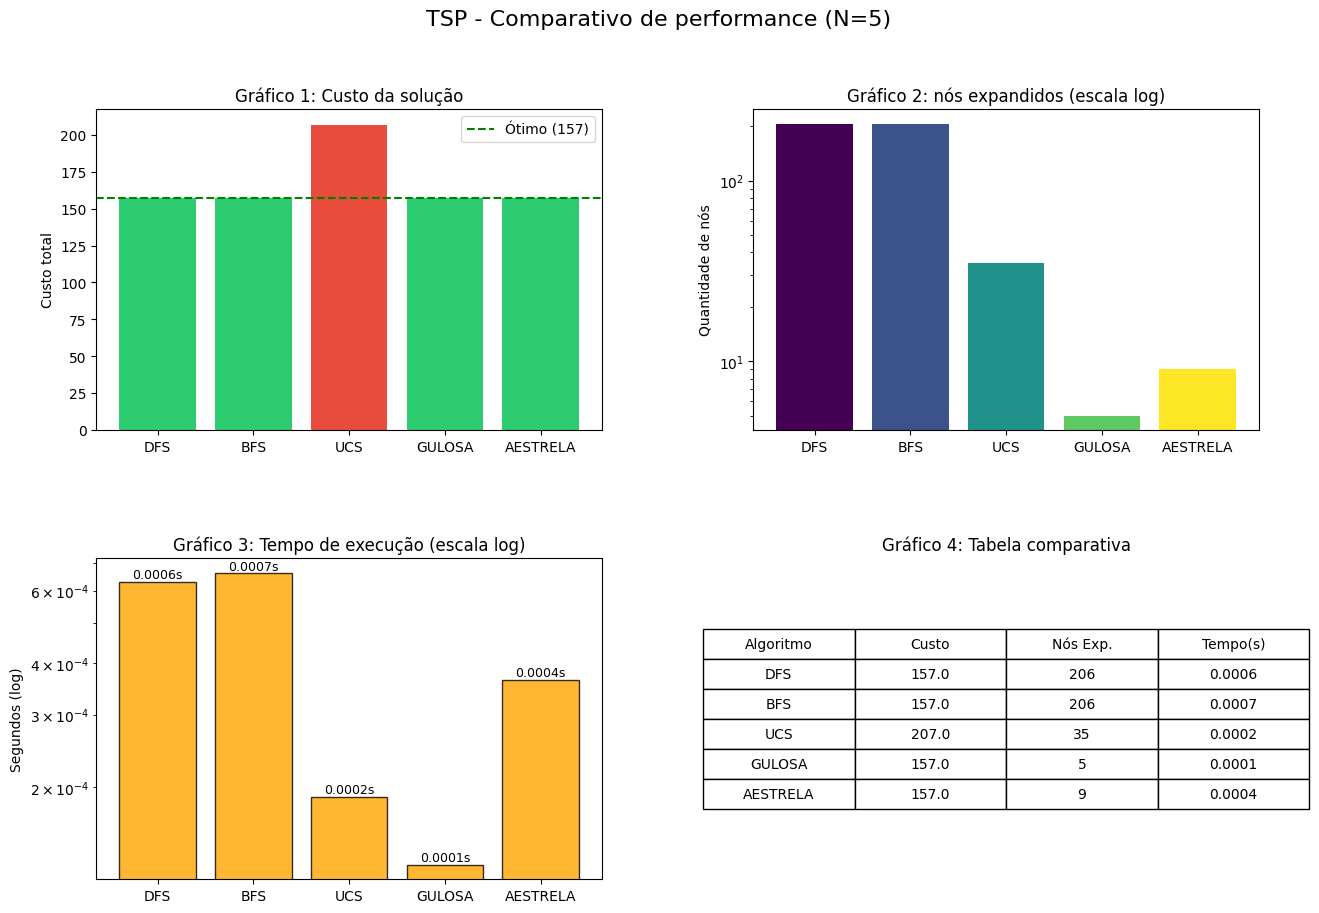

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
import traceback
from grafo import criar_grafo
from dfs import BuscaProfundidade
from bfs import BuscaLargura
from ucs import BuscaCustoUniforme
from gulosa import BuscaGulosa
from aestrela import AEstrela

def main():
    # Configurações iniciais
    num_cidades = 6
    semente = 42 # Defina como None caso não queira valores aleatórios
    cidade_inicial = 0
    grafo = criar_grafo(num_cidades, semente)

    algoritmos_disponiveis = {
        "DFS": BuscaProfundidade,
        "BFS": BuscaLargura,
        "UCS": BuscaCustoUniforme,
        "GULOSA": BuscaGulosa,
        "AESTRELA": AEstrela
    }

    resultados = {}

    print(f"Iniciando TSP com {num_cidades} cidades...")

    for nome, ClasseAlgoritmo in algoritmos_disponiveis.items():
        print(f"> Executando: {nome}...")
        try:
            alg = ClasseAlgoritmo(grafo, cidade_inicial)

            # Execução com medição de tempo
            inicio = time.time()
            alg.buscar()
            fim = time.time()

            # Coleta de dados
            resultados[nome] = {
                "custo": alg.melhor_custo,
                "nos": alg.nos_expandidos,
                "tempo": fim - inicio
            }
        except Exception as e:
            print(f" Erro em {nome}: {e}")

    # Determinar custo ótimo
    custo_otimo = min(res["custo"] for res in resultados.values() if res["custo"] is not None)

    plotar_comparativo(resultados, custo_otimo)

def plotar_comparativo(resultados, custo_otimo):
    algos = list(resultados.keys())
    custos = [res["custo"] for res in resultados.values()]
    nos = [res["nos"] for res in resultados.values()]
    tempos = [res["tempo"] for res in resultados.values()]

    # Configuração da figura (2 linhas, 2 colunas)
    fig, axs = plt.subplots(2, 2, figsize=(15, 10))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    # GRÁFICO 1: CUSTO DA SOLUÇÃO
    cores_custo = ['#2ecc71' if c == custo_otimo else '#e74c3c' for c in custos]
    axs[0, 0].bar(algos, custos, color=cores_custo)
    axs[0, 0].axhline(y=custo_otimo, color='green', linestyle='--', label=f'Ótimo ({custo_otimo})')
    axs[0, 0].set_title("Gráfico 1: Custo da solução")
    axs[0, 0].set_ylabel("Custo total")
    axs[0, 0].legend()

    # GRÁFICO 2: NÓS EXPANDIDOS
    # Cores gradiente baseadas no log dos nós
    cores_nos = plt.cm.viridis(np.linspace(0, 1, len(algos)))
    axs[0, 1].bar(algos, nos, color=cores_nos)
    axs[0, 1].set_yscale('log') # Escala logarítmica
    axs[0, 1].set_title("Gráfico 2: nós expandidos (escala log)")
    axs[0, 1].set_ylabel("Quantidade de nós")

    # GRÁFICO 3: TEMPO DE EXECUÇÃO
    axs[1, 0].bar(algos, tempos, color='orange', alpha=0.8, edgecolor='black')
    axs[1, 0].set_yscale('log')
    axs[1, 0].set_title("Gráfico 3: Tempo de execução (escala log)")
    axs[1, 0].set_ylabel("Segundos (log)")

    # Adiciona os rótulos de tempo em cima das barras para facilitar a leitura
    for i, t in enumerate(tempos):
        axs[1, 0].text(i, t, f'{t:.4f}s', ha='center', va='bottom', fontsize=9)

    # GRÁFICO 4: TABELA COMPARATIVA
    axs[1, 1].axis('off')

    col_labels = ['Algoritmo', 'Custo', 'Nós Exp.', 'Tempo(s)']
    tabela_vals = []

    for nome in algos:
        res = resultados[nome]
        tabela_vals.append([
            nome,
            f"{res['custo']:.1f}",
            f"{res['nos']:,}",
            f"{res['tempo']:.4f}"
        ])
    axs[1, 1].axis('off')

    col_labels = ['Algoritmo', 'Custo', 'Nós Exp.', 'Tempo(s)']
    tabela_vals = []

    for nome in algos:
      res = resultados[nome]
      tabela_vals.append([
          nome,
          f"{res['custo']:.1f}",
          f"{res['nos']:,}",
          f"{res['tempo']:.4f}"
    ])

    tabela = axs[1, 1].table(cellText=tabela_vals, colLabels=col_labels,
                             loc='center', cellLoc='center')
    tabela.auto_set_font_size(False)
    tabela.set_fontsize(10)
    tabela.scale(1.2, 1.8)
    axs[1, 1].set_title("Gráfico 4: Tabela comparativa")

    plt.suptitle(f"TSP - Comparativo de performance (N={len(algos)})", fontsize=16)
    plt.show()

if __name__ == "__main__":
    main()